# 높이 보정 VAA 비교 실험 (2025 정규시즌 학습, 2024·2026 OOS)

v2 웹 모델은 VAA·HAA **원값**을 쓴다. corr(VAA, plate_z) = 0.754 → 원값 VAA 에는 투구 위치(높이) 정보가 섞여 있다 (업무일지 2026-10-05).
위치 효과를 뺀 VAA 가 의미를 유지하면서 위치 의존성을 줄이는지, 그리고 다른 궤적 변수로 위치가 다시 새지 않는지 확인한다.

| 변형 | 3단계 설명변수 |
|---|---|
| **A** v2 | `STUFF_FEATURES_V2` (VAA·HAA 원값) — 웹 모델 `models/v2` 그대로 |
| **B** 높이 보정 | A 에서 `vaa`·`haa` → `vaa_adj`·`haa_adj` |
| **C** 진입각 제거 | `STUFF_FEATURES` (v1 피처), v2 표본으로 재학습 |
| **D** 보정 + 궤적 초기값 제거 | B 에서 `vx0`·`vz0` 제거 |

- 보정 VAA = **같은 구종을 기준 높이(plate_z 2.5ft)에 던졌다면의 VAA** : 구종별 `vaa ~ 1 + plate_z + plate_z²` 를 학습기간 투구로 적합해 위치 효과만 뺀다
  - 위치 변수로만 회귀한다. 릴리스 높이·익스텐션 등 투수 고유 성분은 그대로 남긴다
  - HAA 도 같은 방식 (`plate_x`, 좌투 반전 = 우투 기준, 기준 0 = 플레이트 중앙)
- 1·2단계, split, 3단계 표본, 튜닝(`fit_stuff_model`, n_iter=12), waste 볼 점수 제외는 v2 와 동일
- 실험용 — `stuff_pipeline.py`·`export_web_data.py`·`models/v2` 는 수정하지 않는다. 산출물은 `outputs/vaa_exp/`

In [1]:
import os, gc, warnings, joblib
os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(os.cpu_count()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import log_loss, mean_squared_error, mean_absolute_error, r2_score

import stuff_pipeline as sp
import export_web_data as ew

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 110
SEED = sp.SEED
OUT = os.path.join('outputs', 'vaa_exp')
os.makedirs(OUT, exist_ok=True)

## 0~2. 데이터 · 1·2단계 (v2 와 동일)

In [2]:
df = sp.load_regular_season('games_25_final.pkl')
train_df, valid_df, valid_start = sp.split_last_month(df, months=1)
inner_start = valid_start - pd.Timedelta(days=14)
print(f'정규시즌 {len(df):,} / 학습 {len(train_df):,} / 검증 {len(valid_df):,} (검증 시작 {valid_start.date()})')

hit_model = joblib.load(os.path.join('models', 'stage1_hit_rf.joblib'))
best_rf = {'max_depth': hit_model.max_depth, 'min_samples_leaf': hit_model.min_samples_leaf}
X1_tr, y1_tr = sp.build_hit_dataset(train_df)
X1_va, y1_va = sp.build_hit_dataset(valid_df)
P1_va = hit_model.predict_proba(X1_va)
P1_tr = cross_val_predict(
    RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED, **best_rf), X1_tr, y1_tr,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED), method='predict_proba')
calib = sp.GammaBetaCalibrator().fit(sp.expected_value(P1_tr))
print(calib)
hit_score = pd.concat([pd.Series(calib.transform(sp.expected_value(P1_tr)), index=X1_tr.index),
                       pd.Series(calib.transform(sp.expected_value(P1_va)), index=X1_va.index)])

정규시즌 712,528 / 학습 588,716 / 검증 123,812 (검증 시작 2025-08-29)
GammaBetaCalibrator(gamma_a=0.657, gamma_scale=0.728, beta_a=0.423, beta_b=2.228)


## 3. 높이 보정 VAA·HAA
`adj = 원값 − [f(위치) − f(기준 위치)]`, f = 구종별 2차 다항식 (학습기간 투구로 적합, 표본 500구 미만 구종은 전체 공통식)
- 기준 위치 : VAA 는 plate_z = 2.5ft (존 중앙 높이), HAA 는 plate_x = 0 (플레이트 중앙)
- 잔차의 구종 평균을 0 으로 만들지 않고 기준 위치 값으로 맞추므로, 구종 간 진입각 차이(FF 평평, CU 가파름)는 그대로 남는다

,"corr(vaa, plate_z)","corr(haa, plate_x_r)"
원값,0.754,0.663
보정,0.298,0.200


,n,vaa,vaa_adj,vaa_sd,vaa_adj_sd,haa,haa_adj,corr_z 원값,corr_z 보정
pitch_type,,,,,,,,,
FF,226287,-4.7,-5.08,0.99,0.45,1.27,1.26,0.89,-0.00
SI,110228,-5.86,-5.74,0.99,0.53,0.47,0.63,0.84,-0.00
FC,53670,-6.12,-6.10,1.19,0.63,2.6,2.26,0.85,0.00
CH,73088,-7.46,-6.74,1.09,0.58,0.37,0.73,0.85,0.00
FS,23580,-7.65,-6.86,1.19,0.62,0.64,0.91,0.85,0.01
SL,104854,-7.66,-7.01,1.27,0.78,2.92,2.50,0.79,-0.00
ST,49997,-7.71,-7.11,1.25,1.50,4.23,3.78,0.78,-0.26
SV,3524,-8.63,-7.96,1.22,0.74,3.96,3.61,0.80,0.01
KC,12016,-9.49,-8.64,1.29,0.76,2.87,2.70,0.81,-0.01


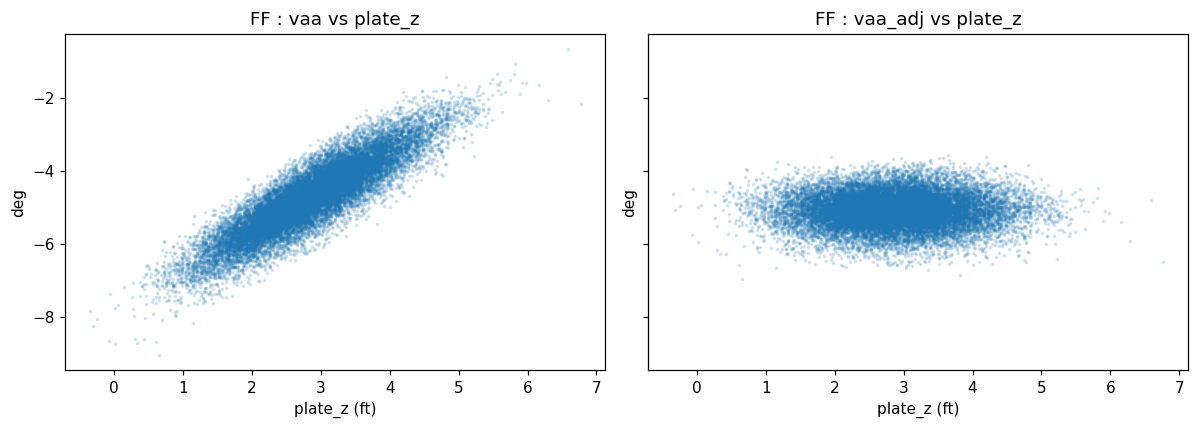

In [3]:
LOC = {'vaa': ('plate_z', 2.5), 'haa': ('plate_x_r', 0.0)}

def add_loc(d):
    d['plate_x_r'] = d['plate_x'].where(d['p_throws'] != 'L', -d['plate_x'])    # 좌투 반전 (HAA 와 같은 기준)
    return d

def num(s):
    return s.to_numpy('float64', na_value=np.nan)

class LocationAdjuster:
    # 구종별 진입각 ~ 1 + 위치 + 위치² -> 기준 위치로 환산
    def fit(self, d, min_n=500):
        self.coef_ = {}
        for ang, (loc, _) in LOC.items():
            ok = d[[ang, loc]].notna().all(axis=1)
            pooled = np.polyfit(num(d.loc[ok, loc]), num(d.loc[ok, ang]), 2)
            self.coef_[ang] = {'_all': pooled}
            for pt, g in d[ok].groupby('pitch_type', observed=True):
                if len(g) >= min_n:
                    self.coef_[ang][str(pt)] = np.polyfit(num(g[loc]), num(g[ang]), 2)
        return self

    def transform(self, d):
        for ang, (loc, ref) in LOC.items():
            x = num(d[loc])
            pt = d['pitch_type'].astype(str).to_numpy()
            corr = np.zeros(len(d))
            for p in np.unique(pt):
                c = self.coef_[ang].get(p, self.coef_[ang]['_all'])
                m = pt == p
                corr[m] = np.polyval(c, x[m]) - np.polyval(c, ref)
            d[f'{ang}_adj'] = num(d[ang]) - np.nan_to_num(corr)    # 위치 결측이면 보정 없음
        return d

feat = add_loc(sp.add_stuff_features(df))
is_train_pitch = feat['game_date'] < valid_start
adjuster = LocationAdjuster().fit(feat[is_train_pitch])
feat = adjuster.transform(feat)
joblib.dump(adjuster, os.path.join(OUT, 'location_adjuster.joblib'))

chk = pd.DataFrame({
    'corr(vaa, plate_z)': [feat['vaa'].corr(feat['plate_z']), feat['vaa_adj'].corr(feat['plate_z'])],
    'corr(haa, plate_x_r)': [feat['haa'].corr(feat['plate_x_r']), feat['haa_adj'].corr(feat['plate_x_r'])],
}, index=['원값', '보정'])
display(chk.round(3))
pt_tab = feat.groupby('pitch_type', observed=True).agg(n=('vaa', 'size'), vaa=('vaa', 'mean'), vaa_adj=('vaa_adj', 'mean'),
        vaa_sd=('vaa', 'std'), vaa_adj_sd=('vaa_adj', 'std'), haa=('haa', 'mean'), haa_adj=('haa_adj', 'mean'))
pt_tab['corr_z 원값'] = feat.groupby('pitch_type', observed=True).apply(lambda g: g['vaa'].corr(g['plate_z']))
pt_tab['corr_z 보정'] = feat.groupby('pitch_type', observed=True).apply(lambda g: g['vaa_adj'].corr(g['plate_z']))
display(pt_tab[pt_tab['n'] >= 1000].sort_values('vaa', ascending=False).round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
s = feat[feat['pitch_type'] == 'FF'].sample(20000, random_state=SEED)
for ax, col in zip(axes, ['vaa', 'vaa_adj']):
    ax.scatter(s['plate_z'], s[col], s=2, alpha=.15)
    ax.set(title=f'FF : {col} vs plate_z', xlabel='plate_z (ft)', ylabel='deg')
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'vaa_adj_ff.png')); plt.show()

## 4. 3단계 모델 A~D (동일 표본·split·튜닝)

In [4]:
V2 = sp.STUFF_FEATURES_V2
B_FEATS = [{'vaa': 'vaa_adj', 'haa': 'haa_adj'}.get(f, f) for f in V2]
FEATS = {'A': V2, 'B': B_FEATS, 'C': sp.STUFF_FEATURES, 'D': [f for f in B_FEATS if f not in ('vx0', 'vz0')]}
NAMES = {'A': 'A v2 (원값)', 'B': 'B 높이 보정', 'C': 'C 진입각 제거', 'D': 'D 보정 + vx0·vz0 제거'}

def split3(X, y):
    is_va = feat.loc[X.index, 'game_date'] >= valid_start
    is_es = (feat.loc[X.index, 'game_date'] >= inner_start) & ~is_va
    return (X[~is_va & ~is_es], y[~is_va & ~is_es]), (X[is_es], y[is_es]), (X[is_va], y[is_va])

ALL_FEATS = list(dict.fromkeys(sum(FEATS.values(), [])))
X3, y3 = sp.build_stuff_dataset(feat, hit_score, features=ALL_FEATS, include_looking_k=False)
(X3_tr, y3_tr), (X3_es, y3_es), (X3_va, y3_va) = split3(X3, y3)
print('train', X3_tr.shape, ' holdout', X3_es.shape, ' valid', X3_va.shape)

models = {'A': joblib.load(os.path.join('models', 'v2', 'stage3_stuff_lgbm.joblib'))}
for k in ['B', 'C', 'D']:
    print(f'--- {NAMES[k]}')
    models[k] = sp.fit_stuff_model(X3_tr[FEATS[k]], y3_tr, X3_es[FEATS[k]], y3_es, n_iter=12, verbose=False)
    print('  best holdout rmse', round(models[k].tuning_results_['rmse'].min(), 5), dict(models[k].tuning_results_.iloc[0, 1:]))
    joblib.dump(models[k], os.path.join(OUT, f'stage3_{k}.joblib'))

train (151051, 24)  holdout (15845, 24)  valid (35291, 24)
--- B 높이 보정


  best holdout rmse 0.16361 {'best_iter': 332.0, 'num_leaves': 63.0, 'min_child_samples': 400.0, 'learning_rate': 0.05, 'colsample_bytree': 1.0, 'subsample': 0.9, 'reg_lambda': 0.0}
--- C 진입각 제거
  best holdout rmse 0.16365 {'best_iter': 519.0, 'num_leaves': 127.0, 'min_child_samples': 200.0, 'learning_rate': 0.02, 'colsample_bytree': 1.0, 'subsample': 0.7, 'reg_lambda': 0.0}
--- D 보정 + vx0·vz0 제거
  best holdout rmse 0.16736 {'best_iter': 1465.0, 'num_leaves': 15.0, 'min_child_samples': 400.0, 'learning_rate': 0.05, 'colsample_bytree': 0.8, 'subsample': 0.7, 'reg_lambda': 5.0}


In [5]:
def reg_metrics(y, p):
    return {'RMSE': np.sqrt(mean_squared_error(y, p)), 'MAE': mean_absolute_error(y, p), 'R2': r2_score(y, p)}

pred_va = {k: m.predict(X3_va[FEATS[k]]) for k, m in models.items()}
metrics3 = pd.DataFrame({NAMES[k]: reg_metrics(y3_va, p) for k, p in pred_va.items()}).T
display(metrics3.round(5))
dec = pd.DataFrame({**pred_va, 'actual': y3_va.values})
display(pd.DataFrame({NAMES[k]: dec.groupby(pd.qcut(dec[k], 10, labels=False))['actual'].mean() for k in models})
        .T.round(4).rename_axis('예측 10분위 → 실제 타구질', axis=1))

,RMSE,MAE,R2
A v2 (원값),0.16215,0.11306,0.09124
B 높이 보정,0.16269,0.11430,0.08521
C 진입각 제거,0.16259,0.11387,0.08634
D 보정 + vx0·vz0 제거,0.16659,0.11973,0.04086


예측 10분위 → 실제 타구질,0,1,2,3,4,5,6,7,8,9
A v2 (원값),0.0097,0.0347,0.0550,0.0718,0.0971,0.1091,0.1238,0.1448,0.1552,0.1749
B 높이 보정,0.0140,0.0369,0.0542,0.0758,0.0911,0.1081,0.1262,0.1440,0.1557,0.1702
C 진입각 제거,0.0124,0.0370,0.0543,0.0756,0.0927,0.1101,0.1224,0.1432,0.1589,0.1695
D 보정 + vx0·vz0 제거,0.0342,0.0591,0.0705,0.0866,0.0944,0.1053,0.1074,0.1320,0.1364,0.1503


### 4-1. 요인 그룹별 기여 (검증 표본 5,000구, TreeSHAP) · gain 중요도
그룹 정의는 웹(`export_web_data.EXPLAIN_GROUPS`)과 같다. `vaa_adj`·`haa_adj` 는 진입각·궤적 그룹

,A v2 (원값),B 높이 보정,C 진입각 제거,D 보정 + vx0·vz0 제거
평균 |그룹 SHAP| ×1000 (예측 단위),,,,
구속,5.24,10.29,9.80,14.25
수직 무브먼트,3.51,13.32,12.77,17.05
수평 무브먼트,3.20,9.63,9.10,10.43
진입각·궤적,35.32,19.68,18.74,9.52
릴리스 위치,9.64,8.00,8.56,6.37
익스텐션,0.93,0.97,1.08,1.94
회전,2.15,2.56,2.61,4.16
구종·투구손,5.07,9.38,9.36,10.43


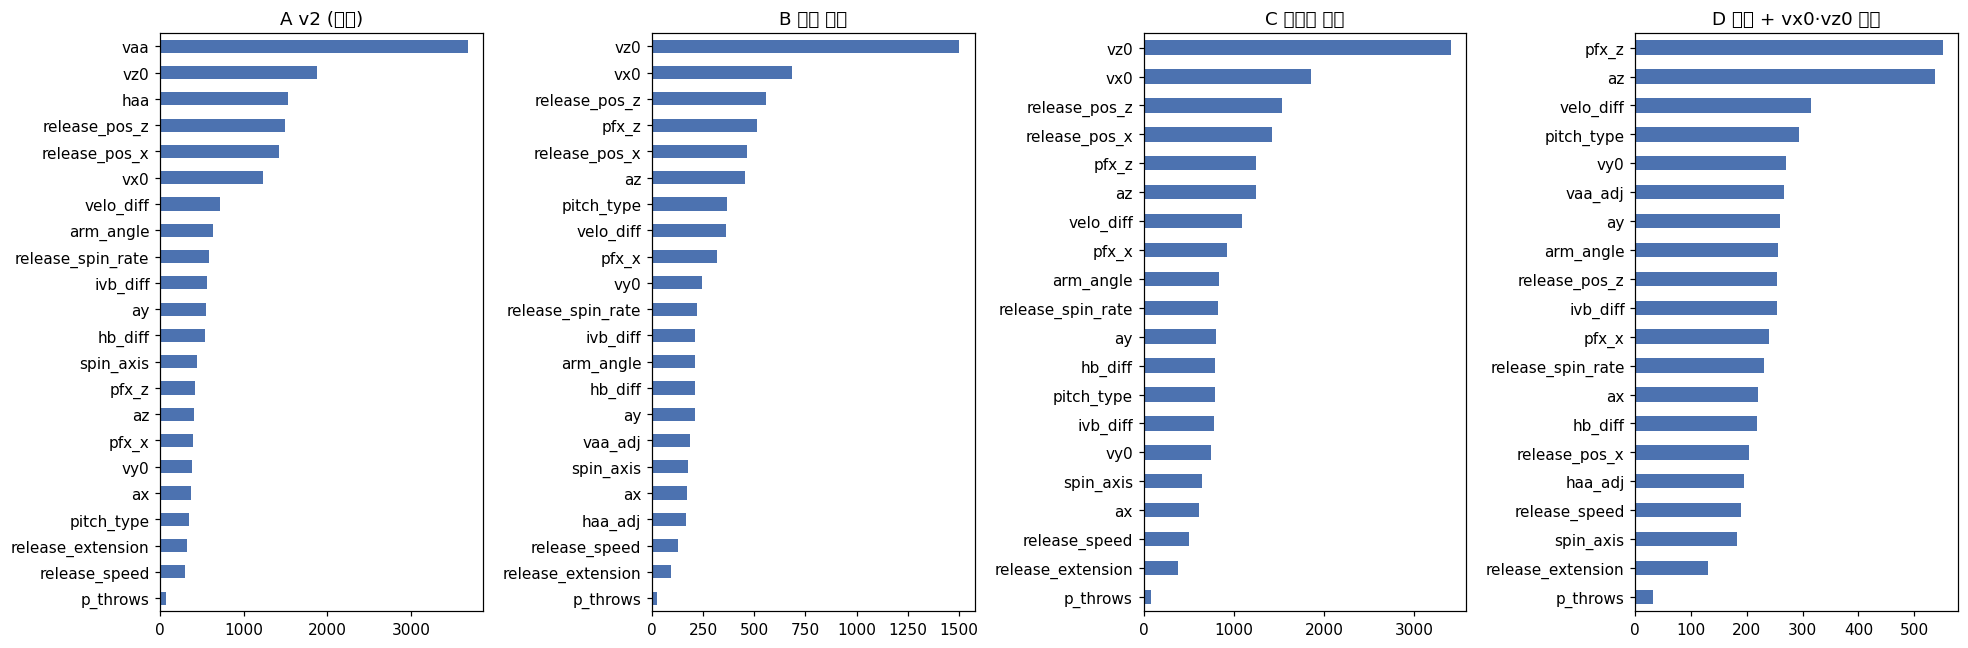

In [6]:
X_shap = X3_va.sample(5000, random_state=SEED)
grp_rows = {}
for k, m in models.items():
    c = m.booster_.predict(X_shap[FEATS[k]], pred_contrib=True)[:, :-1]
    names = [f.replace('_adj', '') for f in FEATS[k]]
    grp_rows[NAMES[k]] = {}
    for g, cols in ew.EXPLAIN_GROUPS:
        idx = [i for i, f in enumerate(names) if f in cols]
        grp_rows[NAMES[k]][g] = np.abs(c[:, idx].sum(axis=1)).mean() if idx else np.nan
grp = pd.DataFrame(grp_rows)
display((grp * 1000).round(2).rename_axis('평균 |그룹 SHAP| ×1000 (예측 단위)'))

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
for ax, (k, m) in zip(axes, models.items()):
    pd.Series(m.booster_.feature_importance('gain'), index=FEATS[k]).sort_values().plot.barh(ax=ax, color='#4C72B0')
    ax.set(title=NAMES[k])
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'importance_gain.png')); plt.show()

### 4-2. 위치 누수 검사
각 변형의 피처만으로 plate_z / plate_x 를 얼마나 맞힐 수 있는지 (LGBM, 학습기간 20만 구로 학습 → 검증기간 R²).
높을수록 모델이 위치를 간접적으로 '볼' 수 있다. 참고로 B 는 `vaa_adj` + (`vz0`·`az` 등으로 재구성되는 원값 VAA) 조합으로 오히려 높이를 역산할 수 있다 → D 와 비교

In [7]:
def leak_r2(feats, target, n=200_000):
    tr = feat[is_train_pitch & feat[target].notna()].sample(n, random_state=SEED)
    va = feat[~is_train_pitch & feat[target].notna()]
    m = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=63, random_state=SEED, verbose=-1)
    m.fit(tr[feats], tr[target])
    return r2_score(va[target], m.predict(va[feats]))

leak = pd.DataFrame({NAMES[k]: {'R²(plate_z)': leak_r2(FEATS[k], 'plate_z'), 'R²(plate_x 우투 기준)': leak_r2(FEATS[k], 'plate_x_r')}
                     for k in models})
display(leak.round(3))

,A v2 (원값),B 높이 보정,C 진입각 제거,D 보정 + vx0·vz0 제거
R²(plate_z),0.970,0.967,0.967,0.869
R²(plate_x 우투 기준),0.987,0.984,0.984,0.788


## 5. 구위 score (20~80, waste 볼 점수 제외) — 변형별 스케일러를 같은 대상 집합으로 적합 (A 는 웹 스케일러)

In [8]:
feat['waste'] = sp.is_waste_ball(feat)
scored = ~feat['waste']
scalers = {'A': joblib.load(os.path.join('models', 'v2', 'stage4_stuff_scaler.joblib'))}
for k, m in models.items():
    feat[f'pred_{k}'] = m.predict(feat[FEATS[k]])
    if k != 'A':
        scalers[k] = sp.StuffScaler().fit(feat.loc[is_train_pitch & scored, f'pred_{k}'])
    feat[f'raw_{k}'] = scalers[k].transform(feat[f'pred_{k}'])          # 점수 제외 전 (진단용)
    feat[f'stuff_{k}'] = feat[f'raw_{k}'].where(scored)
for k in ['B', 'C', 'D']:
    joblib.dump(scalers[k], os.path.join(OUT, f'stage4_{k}.joblib'), compress=3)
display(feat.loc[is_train_pitch, [f'stuff_{k}' for k in models]].describe().round(2))

,stuff_A,stuff_B,stuff_C,stuff_D
count,521147.00,521147.00,521147.00,521147.00
mean,50.00,50.00,50.00,50.00
std,9.98,9.98,9.98,9.98
min,20.00,20.00,20.00,20.00
25%,43.26,43.26,43.26,43.26
50%,50.00,50.00,50.00,50.00
75%,56.74,56.74,56.74,56.74
max,80.00,80.00,80.00,80.00


### 5-1. 검증기간 타당성 (투수×구종 100구+, 투수 300구+) — v2 노트북 5-1 과 같은 정의

In [9]:
SCORE_COLS = {k: f'stuff_{k}' for k in models}

def validity(d):
    d = d.assign(swing=d['description'].isin(ew.SWING_DESC), whiff=d['description'].isin(sp.WHIFF_DESC),
                 xwoba_con=d['estimated_woba_using_speedangle'].where(d['type'] == 'X'))
    out = {}
    for name, col in SCORE_COLS.items():
        pp = (d.groupby(['pitcher', 'pitch_type'], observed=True)
                .agg(n=('swing', 'size'), stuff=(col, 'mean'), sw=('swing', 'sum'), wh=('whiff', 'sum'),
                     xc=('xwoba_con', 'mean')).query('n >= 100'))
        pt = (d.groupby('pitcher').agg(n=('swing', 'size'), stuff=(col, 'mean'), sw=('swing', 'sum'),
                                        wh=('whiff', 'sum')).query('n >= 300'))
        out[NAMES[name]] = {
            '투수×구종 ρ(구위, whiff%)': stats.spearmanr(pp['stuff'], pp['wh'] / pp['sw']).statistic,
            '투수×구종 ρ(구위, xwOBAcon)': stats.spearmanr(pp['stuff'], pp['xc'], nan_policy='omit').statistic,
            '투수 ρ(구위, whiff%)': stats.spearmanr(pt['stuff'], pt['wh'] / pt['sw']).statistic,
        }
    return pd.DataFrame(out)

valid_cmp = validity(feat[~is_train_pitch])
display(valid_cmp.round(3))

,A v2 (원값),B 높이 보정,C 진입각 제거,D 보정 + vx0·vz0 제거
"투수×구종 ρ(구위, whiff%)",0.738,0.711,0.714,0.729
"투수×구종 ρ(구위, xwOBAcon)",-0.286,-0.277,-0.264,-0.246
"투수 ρ(구위, whiff%)",0.590,0.609,0.602,0.555


### 5-2. Out-of-sample 시즌 (2024·2026) — 구간별 결과, 연도 간 안정성, 다음 시즌 whiff% 예측력

In [10]:
cats = models['A'].booster_.pandas_categorical
KEEP = ['pitcher', 'pitch_type', 'p_throws', 'game_date', 'description', 'type', 'events', 'estimated_woba_using_speedangle',
        'plate_x', 'plate_z', 'plate_x_r', 'plate_z_norm', 'zone', 'pa_event', 'is_swing', 'is_whiff', 'result', 'xwoba', 'waste']

def score_oos(path, year):
    raw = sp.load_regular_season(path, year=year)
    d = adjuster.transform(add_loc(sp.add_stuff_features(raw)))
    for col, c in zip(sp.STUFF_CAT_FEATURES, cats):
        d[col] = pd.Categorical(d[col].astype(str), categories=c)
    d = d[d['pitch_type'].notna()]
    d['waste'] = sp.is_waste_ball(d)
    for k, m in models.items():
        d[f'raw_{k}'] = scalers[k].transform(m.predict(d[FEATS[k]]))
        d[f'stuff_{k}'] = d[f'raw_{k}'].where(~d['waste'])
    for col in sp.STUFF_CAT_FEATURES:
        d[col] = d[col].astype(str)
    d = ew.add_web_columns(raw, d)
    return d[KEEP + [f'{p}_{k}' for k in models for p in ('raw', 'stuff')]]

def buckets(d, col):
    bins = pd.cut(d[col], ew.STUFF_BINS, labels=ew.STUFF_BIN_LABELS, right=False)
    rows = {lab: ew.outcome_rates(d[bins == lab]) for lab in ew.STUFF_BIN_LABELS}
    return pd.DataFrame(rows).T[['n', 'ba', 'whiff', 'xwobacon']]

f25 = feat.assign(pitch_type=feat['pitch_type'].astype(str))
seasons = {2025: f25[['pitcher', 'pitch_type', 'game_date', 'description', 'type', 'estimated_woba_using_speedangle', 'waste']
                     + list(SCORE_COLS.values())]}
for year, path in [(2024, 'games_24.pkl'), (2026, 'games_26.pkl')]:
    seasons[year] = score_oos(path, year)
    gc.collect()
    print(year, f'{len(seasons[year]):,}구, waste {seasons[year]["waste"].mean():.1%}')

oos_rows = []
for year in [2024, 2026]:
    for k, col in SCORE_COLS.items():
        b = buckets(seasons[year], col)
        oos_rows.append({'season': year, 'model': NAMES[k],
                         'BA 격차': b.loc['<40', 'ba'] - b.loc['60+', 'ba'],
                         'Whiff 격차': b.loc['60+', 'whiff'] - b.loc['<40', 'whiff'],
                         'xwOBAcon 격차': b.loc['<40', 'xwobacon'] - b.loc['60+', 'xwobacon'],
                         'BA 단조': bool(b['ba'].is_monotonic_decreasing), 'Whiff 단조': bool(b['whiff'].is_monotonic_increasing)})
oos_cmp = pd.DataFrame(oos_rows)
display(oos_cmp.round(3))

2024 708,479구, waste 11.6%
2026 713,177구, waste 14.0%


,season,model,BA 격차,Whiff 격차,xwOBAcon 격차,BA 단조,Whiff 단조
0,2024,A v2 (원값),0.238,0.547,0.155,True,True
1,2024,B 높이 보정,0.227,0.518,0.152,True,True
2,2024,C 진입각 제거,0.232,0.525,0.155,True,True
3,2024,D 보정 + vx0·vz0 제거,0.144,0.348,0.078,True,True
4,2026,A v2 (원값),0.240,0.550,0.146,True,True
5,2026,B 높이 보정,0.230,0.515,0.146,True,True
6,2026,C 진입각 제거,0.237,0.527,0.147,True,True
7,2026,D 보정 + vx0·vz0 제거,0.149,0.331,0.074,True,True


In [11]:
def pt_means(d, col, min_n=100):
    g = d.groupby(['pitcher', 'pitch_type'])[col].agg(['mean', 'count'])
    return g[g['count'] >= min_n]['mean']

def pt_whiff(d, min_n=100):
    g = d.assign(sw=d['description'].isin(ew.SWING_DESC), wh=d['description'].isin(sp.WHIFF_DESC)) \
         .groupby(['pitcher', 'pitch_type']).agg(n=('sw', 'size'), sw=('sw', 'sum'), wh=('wh', 'sum'))
    g = g[g['n'] >= min_n]
    return g['wh'] / g['sw']

stab_rows = {}
for k, col in SCORE_COLS.items():
    r = {}
    for a, b in [(2024, 2025), (2025, 2026)]:
        m = pd.concat([pt_means(seasons[a], col), pt_means(seasons[b], col)], axis=1, join='inner')
        r[f'안정성 r(구위 {a}, 구위 {b})'] = m.corr().iloc[0, 1]
        w = pd.concat([pt_means(seasons[a], col), pt_whiff(seasons[b])], axis=1, join='inner')
        r[f'예측력 ρ(구위 {a}, whiff% {b})'] = stats.spearmanr(w.iloc[:, 0], w.iloc[:, 1]).statistic
    stab_rows[NAMES[k]] = r
stab_cmp = pd.DataFrame(stab_rows)
display(stab_cmp.round(3))

,A v2 (원값),B 높이 보정,C 진입각 제거,D 보정 + vx0·vz0 제거
"안정성 r(구위 2024, 구위 2025)",0.882,0.883,0.880,0.913
"예측력 ρ(구위 2024, whiff% 2025)",0.692,0.673,0.684,0.747
"안정성 r(구위 2025, 구위 2026)",0.862,0.859,0.858,0.904
"예측력 ρ(구위 2025, whiff% 2026)",0.695,0.678,0.676,0.755


## 6. 위치 의존성 (2026 OOS) — 이번 실험의 핵심
- 같은 투수×구종(100구+) 안에서 corr(점수, 높이) · corr(점수, |좌우|) 의 평균 : 구위 모델은 위치를 보지 않아야 하므로 0 에 가까울수록 좋다
- 점수 제외 전 점수(raw)로 : 사구 · waste 볼 · 존 밖(zone 11~14) 볼의 평균 점수, 상위 1% 투구 중 존 밖 볼·사구 비율

In [12]:
d26 = seasons[2026]

def within_corr(d, col, loc, min_n=100):
    x = d[[col, loc, 'pitcher', 'pitch_type']].dropna()
    g = x.groupby(['pitcher', 'pitch_type'])
    n = g.size()
    c = g.apply(lambda t: t[col].corr(t[loc]))
    ok = (n >= min_n) & c.notna()
    return np.average(c[ok], weights=n[ok])

d26 = d26.assign(abs_x=d26['plate_x'].abs(), ball=d26['description'].isin(sp.BALL_DESC), hbp=d26['description'] == 'hit_by_pitch',
                 out_zone=d26['zone'] >= 11)
loc_rows = {}
for k in models:
    raw = f'raw_{k}'
    top = d26[raw] >= d26[raw].quantile(0.99)
    loc_rows[NAMES[k]] = {
        '투수×구종 내 corr(점수, 높이 정규화)': within_corr(d26, f'stuff_{k}', 'plate_z_norm'),
        '투수×구종 내 corr(점수, |plate_x|)': within_corr(d26, f'stuff_{k}', 'abs_x'),
        '사구 평균 점수 (raw)': d26.loc[d26['hbp'], raw].mean(),
        'waste 볼 평균 점수 (raw)': d26.loc[d26['waste'], raw].mean(),
        '존 밖 볼 평균 점수': d26.loc[d26['ball'] & d26['out_zone'] & ~d26['waste'], f'stuff_{k}'].mean(),
        '존 안 투구 평균 점수': d26.loc[~d26['out_zone'], f'stuff_{k}'].mean(),
        '상위 1% 중 존 밖 볼 비율 (raw)': (d26.loc[top, 'ball'] & d26.loc[top, 'out_zone']).mean(),
        '상위 1% 중 사구 비율 (raw)': d26.loc[top, 'hbp'].mean(),
    }
loc_cmp = pd.DataFrame(loc_rows)
display(loc_cmp.round(3))

,A v2 (원값),B 높이 보정,C 진입각 제거,D 보정 + vx0·vz0 제거
"투수×구종 내 corr(점수, 높이 정규화)",0.018,0.009,0.005,-0.110
"투수×구종 내 corr(점수, |plate_x|)",0.430,0.389,0.396,0.050
사구 평균 점수 (raw),67.447,67.048,66.964,54.041
waste 볼 평균 점수 (raw),66.861,65.697,65.502,57.540
존 밖 볼 평균 점수,54.495,53.804,53.818,50.421
존 안 투구 평균 점수,44.375,45.022,44.906,49.119
상위 1% 중 존 밖 볼 비율 (raw),0.925,0.925,0.927,0.763
상위 1% 중 사구 비율 (raw),0.041,0.045,0.047,0.015


In [13]:
SKENES = 694973
sk = d26[d26['pitcher'] == SKENES]
rows = []
for k in models:
    b = pd.cut(sk[f'stuff_{k}'], ew.STUFF_BINS, labels=ew.STUFF_BIN_LABELS, right=False)
    t = sk.groupby(b, observed=False).agg(n=('plate_z_norm', 'size'), z=('plate_z_norm', 'mean'),
                                          out_zone=('zone', lambda s: (s >= 11).mean()))
    t['model'] = NAMES[k]
    rows.append(t.reset_index(names='구간'))
skenes = pd.concat(rows).pivot(index='구간', columns='model', values=['n', 'z', 'out_zone']).reindex(ew.STUFF_BIN_LABELS)
print(f'Skenes 2026 {len(sk):,}구 : 구간별 투구 수 · 평균 높이(정규화, 존 1.5~3.5ft) · 존 밖 비율')
display(skenes.round(2))

Skenes 2026 2,890구 : 구간별 투구 수 · 평균 높이(정규화, 존 1.5~3.5ft) · 존 밖 비율


n                                            z            \
model A v2 (원값) B 높이 보정 C 진입각 제거 D 보정 + vx0·vz0 제거 A v2 (원값)   B 높이 보정   
구간                                                                       
<40         181     180      170                75  2.371376  2.421226   
40-45       315     290      335               285  2.481334  2.549896   
45-50       562     521      531               577  2.529706  2.662031   
50-55       556     574      529               635  2.642683  2.627968   
55-60       449     451      440               498  2.686321  2.576543   
60+         438     485      496               431  2.133103  2.081731   

                                   out_zone                      \
model  C 진입각 제거 D 보정 + vx0·vz0 제거 A v2 (원값)   B 높이 보정  C 진입각 제거   
구간                                                                
<40    2.427697          2.673578  0.016575  0.083333  0.088235   
40-45  2.616673          2.698378   0.11746  0.127586  0.149254   
45-50  2.648026          2.796032  0.206406  0.238004  0.242938   
50-55  2.629846          2.520627  0.390288  0.362369  0.385633   
55-60   2.47073          2.370093   0.76392   0.67184  0.636364   
60+    2.154471          2.038403  0.986301  0.950515  0.947581   

                         
model D 보정 + vx0·vz0 제거  
구간                       
<40            0.346667  
40-45          0.368421  
45-50          0.393414  
50-55          0.390551  
55-60           0.52008  
60+            0.656613

## 7. 종합

In [14]:
comparison = pd.concat([
    metrics3.T.rename(index=lambda s: f'검증 {s} (공통 표본)'),
    valid_cmp.rename(index=lambda s: f'검증 {s}'),
    oos_cmp.set_index(['season', 'model'])[['BA 격차', 'Whiff 격차', 'xwOBAcon 격차']].stack().unstack('model')
        .pipe(lambda x: x.set_axis([f'{a} {b}' for a, b in x.index])),
    stab_cmp,
    leak.rename(index=lambda s: f'누수 {s}'),
    loc_cmp,
    (grp * 1000).rename(index=lambda s: f'|SHAP|×1000 {s}'),
])[[NAMES[k] for k in models]]
for k in ['B', 'C', 'D']:
    comparison[f'{k} − A'] = comparison[NAMES[k]] - comparison[NAMES['A']]
display(comparison.round(4))
comparison.to_csv(os.path.join(OUT, 'comparison.csv'), encoding='utf-8-sig')
skenes.to_csv(os.path.join(OUT, 'skenes_2026_bands.csv'), encoding='utf-8-sig')
pt_tab.to_csv(os.path.join(OUT, 'vaa_adj_by_pitch_type.csv'), encoding='utf-8-sig')

,A v2 (원값),B 높이 보정,C 진입각 제거,D 보정 + vx0·vz0 제거,B − A,C − A,D − A
검증 RMSE (공통 표본),0.1622,0.1627,0.1626,0.1666,0.0005,0.0004,0.0044
검증 MAE (공통 표본),0.1131,0.1143,0.1139,0.1197,0.0012,0.0008,0.0067
검증 R2 (공통 표본),0.0912,0.0852,0.0863,0.0409,-0.0060,-0.0049,-0.0504
"검증 투수×구종 ρ(구위, whiff%)",0.7383,0.7108,0.7144,0.7285,-0.0274,-0.0239,-0.0097
"검증 투수×구종 ρ(구위, xwOBAcon)",-0.2860,-0.2771,-0.2644,-0.2460,0.0089,0.0216,0.0400
"검증 투수 ρ(구위, whiff%)",0.5904,0.6088,0.6021,0.5546,0.0184,0.0117,-0.0358
2024 BA 격차,0.2377,0.2266,0.2322,0.1437,-0.0111,-0.0055,-0.0940
2024 Whiff 격차,0.5469,0.5177,0.5253,0.3485,-0.0293,-0.0216,-0.1985
2024 xwOBAcon 격차,0.1549,0.1517,0.1547,0.0775,-0.0032,-0.0002,-0.0774
2026 BA 격차,0.2405,0.2302,0.2366,0.1495,-0.0103,-0.0039,-0.0910


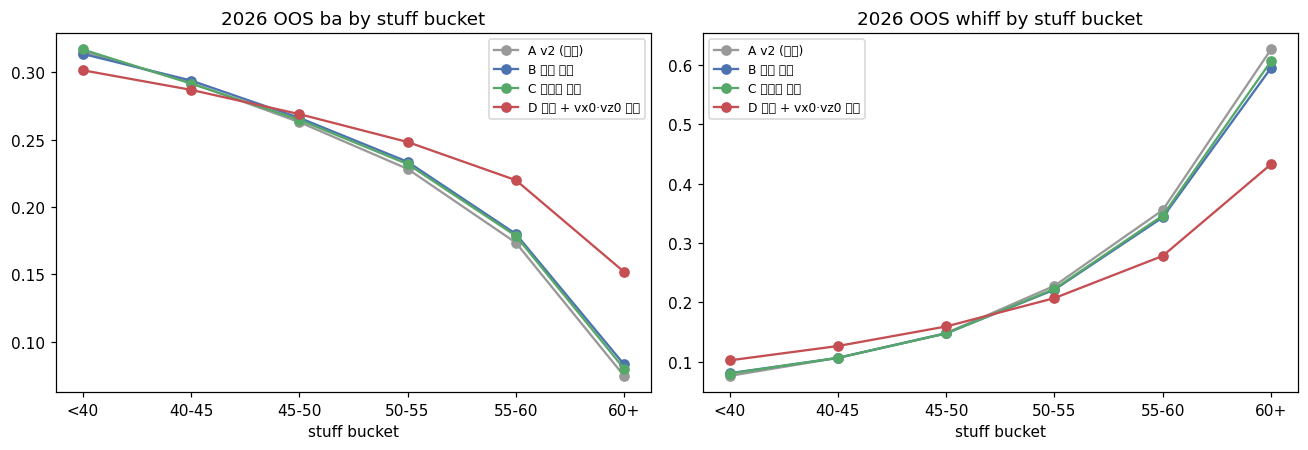

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
colors = {'A': '#999999', 'B': '#4C72B0', 'C': '#55A868', 'D': '#C44E52'}
for ax, metric in zip(axes, ['ba', 'whiff']):
    for k in models:
        b = buckets(seasons[2026], SCORE_COLS[k])
        ax.plot(ew.STUFF_BIN_LABELS, b[metric], marker='o', color=colors[k], label=NAMES[k])
    ax.set(title=f'2026 OOS {metric} by stuff bucket', xlabel='stuff bucket'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'oos_buckets_2026.png')); plt.show()

## 8. 2차 실험 : D 의 남은 위치 누수 끊기 + 높이 치우침 원인

D(보정 VAA + vx0·vz0 제거)도 피처만으로 높이 R² 0.87, 좌우 0.79 를 맞히고, 투수×구종 안 corr(점수, 높이) = −0.11 로 낮은 공을 우대한다.

가설 : `vaa_adj = vaa − f(plate_z)` 인데 원값 VAA 는 릴리스 높이·익스텐션·구속·무브먼트로 거의 계산되므로, `vaa_adj` + 릴리스 정보로 plate_z 를 역산할 수 있다 (HAA·plate_x 도 같음).

### 8-1. 누수 경로 진단 (drop-column)
D 피처에서 하나씩 뺐을 때 위치 R² 가 얼마나 떨어지는지

In [16]:
LEAK_CANDS = ['vaa_adj', 'haa_adj', 'az', 'ax', 'ay', 'vy0', 'release_pos_z', 'release_pos_x', 'pfx_z', 'pfx_x']
base_z, base_x = leak_r2(FEATS['D'], 'plate_z'), leak_r2(FEATS['D'], 'plate_x_r')
drop_rows = {}
for f in LEAK_CANDS:
    fs = [x for x in FEATS['D'] if x != f]
    drop_rows[f] = {'R²(plate_z) 감소': base_z - leak_r2(fs, 'plate_z'), 'R²(plate_x) 감소': base_x - leak_r2(fs, 'plate_x_r')}
leak_drop = pd.DataFrame(drop_rows).T.sort_values('R²(plate_z) 감소', ascending=False)
print(f'D 기준 R² : plate_z {base_z:.3f}, plate_x {base_x:.3f}')
display(leak_drop.round(3))

D 기준 R² : plate_z 0.869, plate_x 0.788


,R²(plate_z) 감소,R²(plate_x) 감소
az,0.437,-0.000
pfx_z,0.354,-0.002
vy0,0.006,0.009
release_pos_z,0.002,-0.002
haa_adj,0.000,-0.001
ax,0.000,0.303
release_pos_x,-0.001,0.004
pfx_x,-0.001,0.150
vaa_adj,-0.002,-0.003
ay,-0.004,0.005


### 8-2. 2차 변형 (동일 split·표본·튜닝)
- **E** : C(v1 피처)에서 vx0·vz0 제거 = D 에서 보정 진입각까지 제거. 진입각 없음
- **F** : E 에서 가속도(ax·ay·az)와 vy0 까지 제거. 무브먼트는 pfx_x·pfx_z, 구속은 release_speed 로 남긴다
- **G** : 진단에서 보정 진입각 외에 위치 R² 를 가장 크게 떨어뜨린 피처 하나를 D 에서 뺀 변형

In [17]:
other = leak_drop.drop(index=['vaa_adj', 'haa_adj'])
g_feat = (other['R²(plate_z) 감소'] + other['R²(plate_x) 감소']).idxmax()
FEATS['E'] = [f for f in sp.STUFF_FEATURES if f not in ('vx0', 'vz0')]
FEATS['F'] = [f for f in FEATS['E'] if f not in ('ax', 'ay', 'az', 'vy0')]
FEATS['G'] = [f for f in FEATS['D'] if f != g_feat]
NAMES.update({'E': 'E 진입각·vx0·vz0 제거', 'F': 'F E + 가속도·vy0 제거', 'G': f'G D − {g_feat}'})
print('G 에서 뺀 피처 :', g_feat)

for k in ['E', 'F', 'G']:
    print(f'--- {NAMES[k]}')
    models[k] = sp.fit_stuff_model(X3_tr[FEATS[k]], y3_tr, X3_es[FEATS[k]], y3_es, n_iter=12, verbose=False)
    print('  best holdout rmse', round(models[k].tuning_results_['rmse'].min(), 5))
    joblib.dump(models[k], os.path.join(OUT, f'stage3_{k}.joblib'))
    feat[f'pred_{k}'] = models[k].predict(feat[FEATS[k]])
    scalers[k] = sp.StuffScaler().fit(feat.loc[is_train_pitch & scored, f'pred_{k}'])
    joblib.dump(scalers[k], os.path.join(OUT, f'stage4_{k}.joblib'), compress=3)
    feat[f'raw_{k}'] = scalers[k].transform(feat[f'pred_{k}'])
    feat[f'stuff_{k}'] = feat[f'raw_{k}'].where(scored)
SCORE_COLS = {k: f'stuff_{k}' for k in models}

G 에서 뺀 피처 : az
--- E 진입각·vx0·vz0 제거
  best holdout rmse 0.16742
--- F E + 가속도·vy0 제거
  best holdout rmse 0.16879
--- G D − az
  best holdout rmse 0.16853


### 8-3. 전체 지표 다시 계산 (A~G)

In [18]:
pred_va = {k: m.predict(X3_va[FEATS[k]]) for k, m in models.items()}
metrics3 = pd.DataFrame({NAMES[k]: reg_metrics(y3_va, p) for k, p in pred_va.items()}).T
valid_cmp = validity(feat[~is_train_pitch])

f25 = feat.assign(pitch_type=feat['pitch_type'].astype(str))
seasons = {2025: f25[['pitcher', 'pitch_type', 'game_date', 'description', 'type', 'estimated_woba_using_speedangle', 'waste']
                     + list(SCORE_COLS.values())]}
for year, path in [(2024, 'games_24.pkl'), (2026, 'games_26.pkl')]:
    seasons[year] = score_oos(path, year)
    gc.collect()

oos_rows = []
for year in [2024, 2026]:
    for k, col in SCORE_COLS.items():
        b = buckets(seasons[year], col)
        oos_rows.append({'season': year, 'model': NAMES[k], 'BA 격차': b.loc['<40', 'ba'] - b.loc['60+', 'ba'],
                         'Whiff 격차': b.loc['60+', 'whiff'] - b.loc['<40', 'whiff'],
                         'xwOBAcon 격차': b.loc['<40', 'xwobacon'] - b.loc['60+', 'xwobacon']})
oos_cmp = pd.DataFrame(oos_rows)

stab_rows = {}
for k, col in SCORE_COLS.items():
    r = {}
    for a, b in [(2024, 2025), (2025, 2026)]:
        m = pd.concat([pt_means(seasons[a], col), pt_means(seasons[b], col)], axis=1, join='inner')
        r[f'안정성 r(구위 {a}, 구위 {b})'] = m.corr().iloc[0, 1]
        w = pd.concat([pt_means(seasons[a], col), pt_whiff(seasons[b])], axis=1, join='inner')
        r[f'예측력 ρ(구위 {a}, whiff% {b})'] = stats.spearmanr(w.iloc[:, 0], w.iloc[:, 1]).statistic
    stab_rows[NAMES[k]] = r
stab_cmp = pd.DataFrame(stab_rows)

leak = pd.DataFrame({NAMES[k]: {'R²(plate_z)': leak_r2(FEATS[k], 'plate_z'), 'R²(plate_x 우투 기준)': leak_r2(FEATS[k], 'plate_x_r')} for k in models})

d26 = seasons[2026]
d26 = d26.assign(abs_x=d26['plate_x'].abs(), ball=d26['description'].isin(sp.BALL_DESC), hbp=d26['description'] == 'hit_by_pitch', out_zone=d26['zone'] >= 11)
loc_rows = {}
for k in models:
    raw = f'raw_{k}'
    top = d26[raw] >= d26[raw].quantile(0.99)
    loc_rows[NAMES[k]] = {
        '투수×구종 내 corr(점수, 높이 정규화)': within_corr(d26, f'stuff_{k}', 'plate_z_norm'),
        '투수×구종 내 corr(점수, |plate_x|)': within_corr(d26, f'stuff_{k}', 'abs_x'),
        '사구 평균 점수 (raw)': d26.loc[d26['hbp'], raw].mean(),
        'waste 볼 평균 점수 (raw)': d26.loc[d26['waste'], raw].mean(),
        '상위 1% 중 존 밖 볼 비율 (raw)': (d26.loc[top, 'ball'] & d26.loc[top, 'out_zone']).mean(),
        '상위 1% 중 사구 비율 (raw)': d26.loc[top, 'hbp'].mean(),
    }
loc_cmp = pd.DataFrame(loc_rows)

grp_rows = {}
for k, m in models.items():
    c = m.booster_.predict(X_shap[FEATS[k]], pred_contrib=True)[:, :-1]
    names = [f.replace('_adj', '') for f in FEATS[k]]
    grp_rows[NAMES[k]] = {}
    for g, cols in ew.EXPLAIN_GROUPS:
        idx = [i for i, f in enumerate(names) if f in cols]
        grp_rows[NAMES[k]][g] = np.abs(c[:, idx].sum(axis=1)).mean() if idx else np.nan
grp = pd.DataFrame(grp_rows)

comparison2 = pd.concat([
    metrics3.T.rename(index=lambda s: f'검증 {s} (공통 표본)'),
    valid_cmp.rename(index=lambda s: f'검증 {s}'),
    oos_cmp.set_index(['season', 'model'])[['BA 격차', 'Whiff 격차', 'xwOBAcon 격차']].stack().unstack('model')
        .pipe(lambda x: x.set_axis([f'{a} {b}' for a, b in x.index])),
    stab_cmp,
    leak.rename(index=lambda s: f'누수 {s}'),
    loc_cmp,
    (grp * 1000).rename(index=lambda s: f'|SHAP|×1000 {s}'),
])[[NAMES[k] for k in models]]
display(comparison2.round(4))
comparison2.to_csv(os.path.join(OUT, 'comparison_round2.csv'), encoding='utf-8-sig')
leak_drop.to_csv(os.path.join(OUT, 'leak_drop_D.csv'), encoding='utf-8-sig')

,A v2 (원값),B 높이 보정,C 진입각 제거,D 보정 + vx0·vz0 제거,E 진입각·vx0·vz0 제거,F E + 가속도·vy0 제거,G D − az
검증 RMSE (공통 표본),0.1622,0.1627,0.1626,0.1666,0.1666,0.1682,0.1679
검증 MAE (공통 표본),0.1131,0.1143,0.1139,0.1197,0.1194,0.1223,0.1217
검증 R2 (공통 표본),0.0912,0.0852,0.0863,0.0409,0.0410,0.0222,0.0253
"검증 투수×구종 ρ(구위, whiff%)",0.7383,0.7108,0.7144,0.7285,0.7293,0.7240,0.7111
"검증 투수×구종 ρ(구위, xwOBAcon)",-0.2860,-0.2771,-0.2644,-0.2460,-0.2617,-0.2432,-0.2484
"검증 투수 ρ(구위, whiff%)",0.5904,0.6088,0.6021,0.5546,0.5807,0.5485,0.5635
2024 BA 격차,0.2377,0.2266,0.2322,0.1437,0.1493,0.1141,0.1166
2024 Whiff 격차,0.5469,0.5177,0.5253,0.3485,0.3530,0.2434,0.2558
2024 xwOBAcon 격차,0.1549,0.1517,0.1547,0.0775,0.0830,0.0567,0.0610
2026 BA 격차,0.2405,0.2302,0.2366,0.1495,0.1501,0.1196,0.1225


### 8-4. 높이 치우침 원인
- 구종별로 나눈 투수×구종 내 corr(점수, 높이 정규화) (2026 OOS)
- D 에서 vaa_adj 기여(SHAP)와 plate_z 의 상관 (2025 검증 표본 5,000구)

In [19]:
pts_main = ['FF', 'SI', 'FC', 'SL', 'ST', 'CH', 'FS', 'CU', 'KC']
bias = pd.DataFrame({NAMES[k]: {pt: within_corr(d26[d26['pitch_type'] == pt], f'stuff_{k}', 'plate_z_norm') for pt in pts_main} for k in models})
display(bias.round(3))
bias.to_csv(os.path.join(OUT, 'height_bias_by_pitch_type.csv'), encoding='utf-8-sig')

cD = models['D'].booster_.predict(X_shap[FEATS['D']], pred_contrib=True)[:, :-1]
z = feat.loc[X_shap.index, 'plate_z'].to_numpy('float64', na_value=np.nan)
ok = ~np.isnan(z)
for f in ['vaa_adj', 'haa_adj']:
    j = FEATS['D'].index(f)
    print(f'D : corr({f} SHAP, plate_z) = {np.corrcoef(cD[ok, j], z[ok])[0, 1]:+.3f}  (부호 : 예측값 기여, + = 타구질 나쁨 = 구위 낮음)')

,A v2 (원값),B 높이 보정,C 진입각 제거,D 보정 + vx0·vz0 제거,E 진입각·vx0·vz0 제거,F E + 가속도·vy0 제거,G D − az
FF,0.656,0.666,0.661,0.408,0.439,0.037,0.048
SI,0.149,0.161,0.165,-0.048,0.006,-0.065,-0.032
FC,0.099,0.129,0.147,-0.238,-0.162,-0.013,-0.134
SL,-0.558,-0.622,-0.623,-0.675,-0.681,-0.190,-0.284
ST,-0.494,-0.546,-0.556,-0.496,-0.487,-0.089,-0.195
CH,-0.592,-0.622,-0.647,-0.444,-0.456,-0.099,-0.070
FS,-0.717,-0.758,-0.769,-0.585,-0.592,-0.120,-0.101
CU,-0.733,-0.752,-0.770,-0.526,-0.533,-0.239,-0.297
KC,-0.800,-0.822,-0.826,-0.570,-0.578,-0.301,-0.351


D : corr(vaa_adj SHAP, plate_z) = -0.384  (부호 : 예측값 기여, + = 타구질 나쁨 = 구위 낮음)
D : corr(haa_adj SHAP, plate_z) = +0.010  (부호 : 예측값 기여, + = 타구질 나쁨 = 구위 낮음)


### 판정 (1차 + 2차)

**1차 (A~D)**
- 높이 보정 VAA(B)만으로는 위치 누수가 거의 줄지 않는다 (plate_z R² 0.970 → 0.967, 진입각을 아예 뺀 C 도 0.967). 위치는 궤적 초기값으로 재구성된다.
- D(보정 + vx0·vz0 제거)는 위치 의존성을 크게 줄였지만 plate_z R² 0.87 이 남았고, 투수×구종 내 corr(점수, 높이) −0.11 의 치우침이 생겼다.

**2차 — 남은 누수 경로 (8-1)**
- D 에서 하나씩 뺐을 때 plate_z R² 감소 : `az` 0.44, `pfx_z` 0.35 / plate_x : `ax` 0.30, `pfx_x` 0.15. 나머지는 0.01 미만.
- 궤적 파라미터는 등가속도 운동식으로 홈플레이트 위치를 그대로 정한다 (2025 전체 709,966구에서 물리식 재현 R² 0.99998, 오차 중앙값 0.035 in).
- D 의 vaa_adj 기여(SHAP)는 plate_z 와 상관 −0.38 : 보정 VAA 자체가 릴리스 정보와 함께 높이를 다시 알려 준다.

**2차 — 변형 비교 (8-3)**

| | A v2 (웹) | D | E | F | G |
|---|---|---|---|---|---|
| 누수 R² plate_z / plate_x | 0.970 / 0.987 | 0.869 / 0.788 | 0.872 / 0.789 | **0.281 / 0.178** | 0.432 / 0.789 |
| 투수×구종 ρ(구위, whiff%) | **0.738** | 0.729 | 0.729 | 0.724 | 0.711 |
| 안정성 r 24→25 / 25→26 | 0.882 / 0.862 | 0.913 / 0.904 | 0.909 / 0.904 | **0.940 / 0.938** | 0.925 / 0.921 |
| 다음 시즌 whiff% ρ | 0.692 / 0.695 | 0.747 / 0.755 | 0.751 / 0.751 | **0.778 / 0.775** | 0.756 / 0.767 |
| 투수×구종 내 corr(점수, 높이) / (점수, \|좌우\|) | 0.018 / 0.430 | −0.110 / 0.050 | −0.085 / 0.052 | −0.062 / **0.025** | −0.082 / 0.063 |
| 사구 평균 점수 (raw) | 67.4 | 54.0 | 53.9 | **50.7** | 52.2 |
| 상위 1% 중 존 밖 볼 | 92.5% | 76.3% | 77.1% | **41.0%** | 47.9% |
| 검증 R² / 2026 Whiff 격차 | **0.091 / 0.550** | 0.041 / 0.331 | 0.041 / 0.339 | 0.022 / 0.241 | 0.025 / 0.249 |

**2차 — 높이 치우침 (8-4)**
- A 의 전체 corr(점수, 높이) 0.018 은 구종별 반대 방향이 상쇄된 값이다 : FF +0.66 (높은 포심일수록 점수↑), SL −0.56 · CH −0.59 · CU −0.73 · KC −0.80 (낮은 변화구일수록 점수↑).
- F 는 FF +0.04, 변화구 −0.09 ~ −0.30 으로 크게 줄었다. 커브·너클커브의 −0.24 ~ −0.30 이 남은 치우침이다.

**결론**
- 위치 누수의 주 경로는 VAA 가 아니라 **궤적 초기값(vx0·vz0)과 가속도(ax·az)**. VAA 보정만으로는 해결되지 않는다.
- **F(구속·무브먼트(pfx)·회전·릴리스·익스텐션·팔각도 + 패스트볼 대비 차이 + 구종·투구손)** 가 v3 후보 기준(누수 감소, 안정성·예측력 ≥ D, ρ whiff% 하락 0.014 < 0.03)을 모두 만족하는 유일한 변형이다. 단 투수×구종 내 corr(점수, 높이) −0.062 로 기준(|0.05|)을 약간 넘는다.
- 대가 : 투구 단위 적합도(R² 0.091 → 0.022)와 구위 구간별 결과 격차(Whiff 격차 0.55 → 0.24)가 크게 줄어든다. 위치 덕분의 '맞힘'이 빠진 결과.
- 다음 실험 제안 : plate_x·plate_z 를 피처에 넣고 학습한 뒤 점수 산정 때 위치를 리그 구종별 분포로 평균(위치 중립 예측) — F 와 비교. 웹 반영은 사용자 결정.